<a href="https://colab.research.google.com/github/ashrafsohail42003/Training-project/blob/main/Purpose_of_L1_or_L2_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn import set_config
set_config(transform_output='pandas')

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
def classification_metrics(y_true, y_pred, label="", output_dict=False, figsize=(8,4), normalize='true', cmap='Blues', colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)
  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)
  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', colorbar=colorbar,
                ax = axes[0],);
  axes[0].set_title("Raw Counts")
  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, colorbar=colorbar,
                ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")
  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict



def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                     output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                  output_dict=True,figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_test,
                                    label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,
                    'test': results_test}
    return results_dict

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
filename = '/content/drive/MyDrive/AXSOSACADEMY/02-IntroML/Week06/Data/pd_speech_features.csv'
df = pd.read_csv(filename)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 755 entries, id to class
dtypes: float64(749), int64(6)
memory usage: 4.4 MB


,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1


In [17]:
df.isna().sum().sum()

np.int64(0)

In [18]:
df.dtypes.unique()

array([dtype('int64'), dtype('float64')], dtype=object)

In [19]:
X = df.drop(columns=['id','class'])
y =df['class']
X_train ,X_test ,y_train ,y_test = train_test_split(X ,y ,random_state=42)


In [20]:
y_train.value_counts(normalize=True)

,proportion
class,
1,0.751323
0,0.248677


In [21]:
logreg = LogisticRegression(max_iter=500 ,random_state=42)
scaler  = StandardScaler()
logreg_pipe = make_pipeline(scaler , logreg)
logreg_pipe.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(max_iter=500, random_state=42))])

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       141
           1       1.00      1.00      1.00       426

    accuracy                           1.00       567
   macro avg       1.00      1.00      1.00       567
weighted avg       1.00      1.00      1.00       567



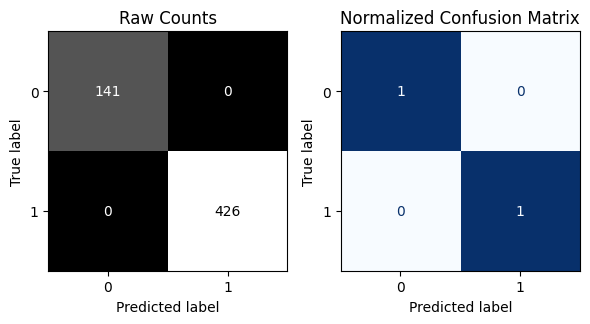


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.72      0.55      0.62        51
           1       0.85      0.92      0.88       138

    accuracy                           0.82       189
   macro avg       0.78      0.73      0.75       189
weighted avg       0.81      0.82      0.81       189



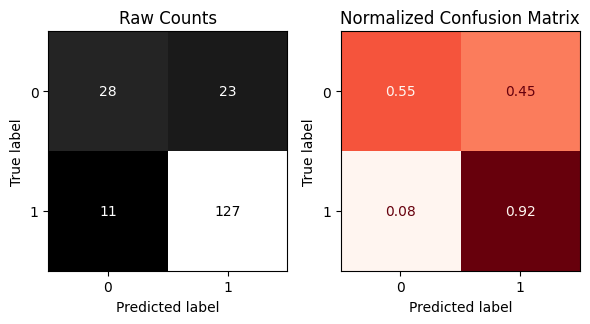

In [22]:
evaluate_classification(logreg_pipe, X_train, y_train, X_test, y_test)


In [23]:
log_pipe = make_pipeline(scaler ,LogisticRegression(penalty='l1',random_state=42,max_iter=500))
logreg_pipe.get_params()


{'memory': None,
 'steps': [('standardscaler', StandardScaler()),
  ('logisticregression', LogisticRegression(max_iter=500, random_state=42))],
 'transform_input': None,
 'verbose': False,
 'standardscaler': StandardScaler(),
 'logisticregression': LogisticRegression(max_iter=500, random_state=42),
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'logisticregression__C': 1.0,
 'logisticregression__class_weight': None,
 'logisticregression__dual': False,
 'logisticregression__fit_intercept': True,
 'logisticregression__intercept_scaling': 1,
 'logisticregression__l1_ratio': None,
 'logisticregression__max_iter': 500,
 'logisticregression__multi_class': 'deprecated',
 'logisticregression__n_jobs': None,
 'logisticregression__penalty': 'l2',
 'logisticregression__random_state': 42,
 'logisticregression__solver': 'lbfgs',
 'logisticregression__tol': 0.0001,
 'logisticregression__verbose': 0,
 'logisticregression__warm_start': False}

In [25]:
params={'logisticregression__C': [0.0001, 0.001,0.01, 0.1, 1, 10, 100, 1000]}
# Instantiate GS with scoring = 'recall_macro' and return_train_score = True
gs = GridSearchCV(logreg_pipe, params,verbose=True, n_jobs=-1,
                  return_train_score=True,scoring='recall_macro')
# Fit the gridsearch on the training data
gs.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('logisticregression',
                                        LogisticRegression(max_iter=500,
                                                           penalty='l1',
                                                           random_state=42,
                                                           solver='liblinear'))]),
             n_jobs=-1,
             param_grid={'logisticregression__C': [0.0001, 0.001, 0.01, 0.1, 1,
                                                   10, 100, 1000]},
             return_train_score=True, scoring='recall_macro', verbose=True)

In [24]:
# Remaking the model with solver='liblinear'
logreg_pipe = make_pipeline(scaler, LogisticRegression(solver='liblinear',
                                                       max_iter=500,
                                                       penalty='l1',
                                                       random_state=42))
# Define the param grid
params={'logisticregression__C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]}
# Create the GridSearchCV object with required args
gs = GridSearchCV(logreg_pipe, params, verbose=True, n_jobs=-1,
                  return_train_score=True,scoring='recall_macro')
# Fit the gridsearch and display best params
gs.fit(X_train, y_train)
print(f'Best Params: {gs.best_params_}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'logisticregression__C': 100}


In [26]:
# Making a dataframe with cv_results_
cv_results = pd.DataFrame(gs.cv_results_)
# Save the train/test scores + value for C
scores = cv_results[['param_logisticregression__C','mean_train_score','mean_test_score']]
scores = scores.set_index('param_logisticregression__C')
scores

,mean_train_score,mean_test_score
param_logisticregression__C,,
0.0001,0.500000,0.500000
0.0010,0.500000,0.500000
0.0100,0.500000,0.500000
0.1000,0.817432,0.725964
1.0000,1.000000,0.765407
10.0000,1.000000,0.764191
100.0000,1.000000,0.777356
1000.0000,1.000000,0.771597


param_logisticregression__C
0.0001       0.500000
0.0010       0.500000
0.0100       0.500000
0.1000       0.725964
1.0000       0.765407
10.0000      0.764191
100.0000     0.777356
1000.0000    0.771597
Name: mean_test_score, dtype: float64


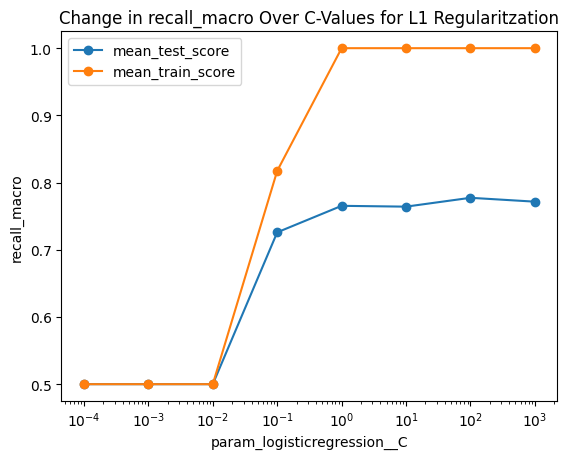

In [27]:
ax = scores.plot(y=['mean_test_score','mean_train_score'],
            style='o-',logx=True)
ax.set(ylabel=gs.scoring,
       title=f'Change in {gs.scoring} Over C-Values for L1 Regularitzation')
print(scores['mean_test_score'])

In [29]:
def plot_cv_results(gs, param_name='param_logisticregression__C', logx = True):
  cv_results = pd.DataFrame(gs.cv_results_)
  scores = cv_results[[param_name,'mean_train_score','mean_test_score']]
  scores = scores.set_index(param_name)
  ax = scores.plot(y=['mean_test_score','mean_train_score'],
              style='o-',logx=logx)
  ax.set(ylabel=gs.scoring)
  print(scores['mean_test_score'])
  return ax

param_logisticregression__C
0.0001       0.500000
0.0010       0.500000
0.0100       0.500000
0.1000       0.725964
1.0000       0.765407
10.0000      0.764191
100.0000     0.777356
1000.0000    0.771597
Name: mean_test_score, dtype: float64


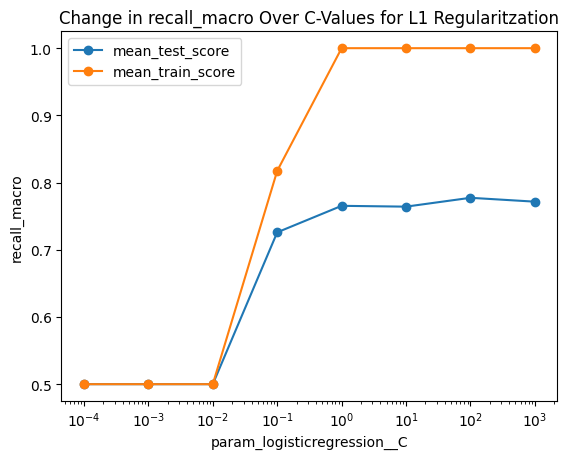

In [30]:
ax = plot_cv_results(gs)
ax.set_title(f'Change in {gs.scoring} Over C-Values for L1 Regularitzation');

In [31]:
logreg_pipe = make_pipeline(scaler, LogisticRegression(solver='liblinear',
                                                       max_iter=500,
                                                       penalty='l2',
                                                       random_state=42))
# Define the params and instantiate gridsearch
params={'logisticregression__C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]}
gs = GridSearchCV(logreg_pipe, params,verbose=True, n_jobs=-1,
                  return_train_score=True,scoring='recall_macro')
# Fit gridsearch and display best params
gs.fit(X_train, y_train)
gs.best_params_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


{'logisticregression__C': 0.1}

param_logisticregression__C
0.0001       0.715964
0.0010       0.746396
0.0100       0.763730
0.1000       0.769133
1.0000       0.765698
10.0000      0.756423
100.0000     0.756521
1000.0000    0.756369
Name: mean_test_score, dtype: float64


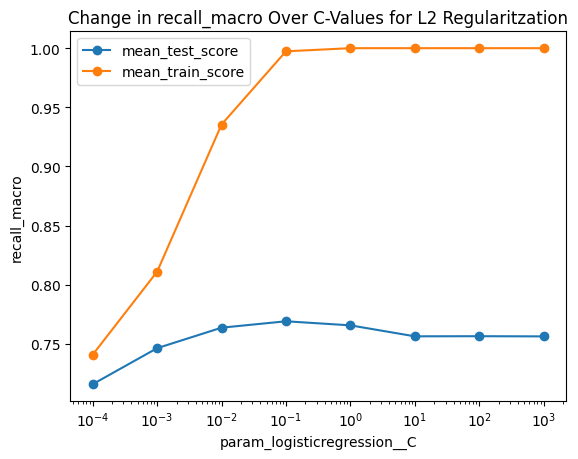

In [32]:
ax = plot_cv_results(gs)
ax.set_title(f'Change in {gs.scoring} Over C-Values for L2 Regularitzation');

In [33]:
# Making a logreg pipe that uses elasticnet regularization
logreg_pipe = make_pipeline(scaler, LogisticRegression(solver='saga', penalty='elasticnet', max_iter=2500, random_state=42))
# Define l1_ratio params
params={
    'logisticregression__l1_ratio':[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
    }
# Create and fit the gridsearch and display results
gs = GridSearchCV(logreg_pipe, params,verbose=True, n_jobs=-1,cv=3,
                  return_train_score=True,scoring='recall_macro')
gs.fit(X_train, y_train)
gs.best_params_

Fitting 3 folds for each of 11 candidates, totalling 33 fits


{'logisticregression__l1_ratio': 0.1}

param_logisticregression__l1_ratio
0.0    0.780516
0.1    0.782839
0.2    0.772201
0.3    0.762736
0.4    0.762711
0.5    0.767431
0.6    0.768605
0.7    0.765058
0.8    0.765058
0.9    0.763885
1.0    0.761512
Name: mean_test_score, dtype: float64


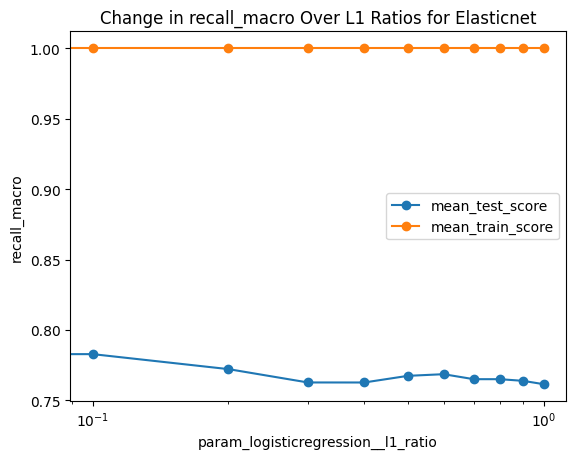

In [34]:
ax = plot_cv_results(gs, param_name='param_logisticregression__l1_ratio')
ax.set_title(f'Change in {gs.scoring} Over L1 Ratios for Elasticnet');

param_logisticregression__l1_ratio
0.0    0.780516
0.1    0.782839
0.2    0.772201
0.3    0.762736
0.4    0.762711
0.5    0.767431
0.6    0.768605
0.7    0.765058
0.8    0.765058
0.9    0.763885
1.0    0.761512
Name: mean_test_score, dtype: float64


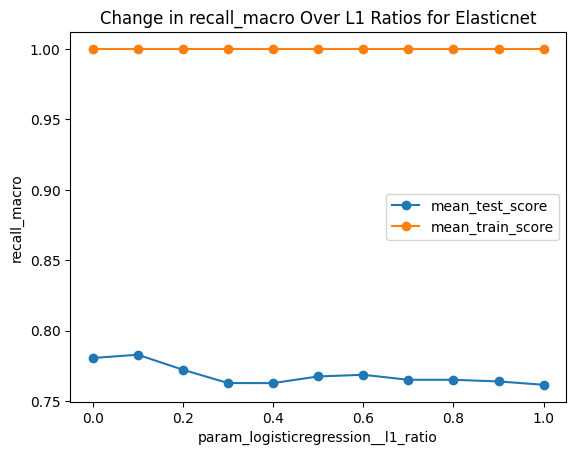

In [35]:
ax = plot_cv_results(gs, param_name='param_logisticregression__l1_ratio', logx = False)
ax.set_title(f'Change in {gs.scoring} Over L1 Ratios for Elasticnet');

In [36]:
logreg_pipe = make_pipeline(scaler, LogisticRegression(max_iter=1000,random_state=42))

In [37]:
elasticnet_params = {'logisticregression__solver' : ['saga'],
               'logisticregression__penalty' : ['elasticnet'],
                'logisticregression__l1_ratio': [0, 0.1, 0.2, 0.3, 0.4,
                                                 0.5, 0.6, 0.7, 0.8, 0.9, 1]}
# Params compatible with penality='l2'
l2_params = {'logisticregression__solver': ['lbfgs', 'liblinear', 'newton-cg',
                                            'newton-cholesky', 'sag', 'saga'],
                  'logisticregression__penalty' : ['l2'],
                  'logisticregression__C': [0.0001, 0.001, 0.01, 0.1,
                                            1, 10, 100, 1000] }
# Params compatible with penality='l1'
l1_params = {'logisticregression__solver' : ['liblinear', 'saga'],
               'logisticregression__penalty' : ['l1'],
                'logisticregression__C': [0.0001, 0.001, 0.01, 0.1, 1,
                                          10, 100, 1000]}
# Params with no penality
none_params = {'logisticregression__solver' : ['lbfgs', 'newton-cg',
                                               'newton-cholesky', 'sag', 'saga'],
               'logisticregression__penalty' : [None]}
# Now make a list of the param dictionaries
param_grid = [l2_params, l1_params, elasticnet_params, none_params]

In [38]:
gs = GridSearchCV(logreg_pipe, param_grid, verbose = 5, n_jobs = -1,
                  scoring='recall_macro')
# Fit the gs on the training data only
gs.fit(X_train, y_train)
gs.best_params_

Fitting 5 folds for each of 80 candidates, totalling 400 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


{'logisticregression__l1_ratio': 0.1,
 'logisticregression__penalty': 'elasticnet',
 'logisticregression__solver': 'saga'}